# Heart Disease Classification Pipeline: Synthetic Data Generation & Explainable AI

#### Technical Artefact - Final Year Project

## Overview:
In this notebook, we will look at the implementation of a complete binary classification pipeline for heart disease. In addition to the standard process of training various machine learning models to select the best one, we will see how the use of synthetic data generated using GPT-GANs can help address various issues associated with clinical data collection (such as privacy concerns, as well as the scarcity of such data, given how difficult it is to obtain).

We will also analyse how models make decisions using techniques such as feature importance and SHAP, gaining an understanding of how a model makes a particular choice. Furthermore, we will examine the social impact that a machine learning model can have by conducting a fairness analysis on both the data and the models.

### Objectives:

1. Data Acquisition: loading the clinical heart disease dataset.
2. Synthetic Data Generation: creation of a synthetic dataset of 10,000 records using CTGAN for high-fidelity tabular data.
3. Comparative EDA: statistical and visual analysis of the distribution of the synthetic dataset versus the real dataset.
4. ML Pipeline (Preprocessing and Training): a machine learning pipeline using the sklearn pipeline, ranging from data pre-processing to training different classifiers using synthetic data exclusively.
5. Model Evaluation: testing different classifiers on the unseen real-world dataset following the Train Synthetic, Test Real approach.
6. Explainability: feature importance analysis and SHAP to understand the decisions made by complex models.
7. Fairness Analysis: to investigate the social impact that the model or data has on specific subgroups (e.g. gender, age, etc.).


## Basic setup:

In [1]:
import sys
from pathlib import Path

# add the root folder to the python path 
# (this fixes problems with importing modules inside the notebook)
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

# data manipulation libraries
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# custom EDA modules
from src.eda_utils import plot_hist, plot_bar, plot_box, calculate_statistics
from src.eda_utils import frequency_table, statistical_tests, numeric_biv_analysis
from src.eda_utils import qualitative_association, plot_corr_matrix

# custom data loader module
from src.data_loader import load_data

# custom synthetic generation module
from src.synthesizer import generate_syn_df, diagnostic_report, quality_report, get_column_plot



We prepare the data we are going to use, both the real and the synthetic data.

In [2]:
# load original dataset 
df = load_data()
print(df.head())

# generate synthetic data
syn_df = generate_syn_df(df, n_epochs=300)
print(syn_df.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
Loading existing model: C:\Users\Riccardo\Desktop\computer-science-project\models\ctgan_300_epochs.pkl
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   56   M           AS

c:\Users\Riccardo\miniconda3\envs\project_env\Lib\site-packages\sdv\_utils.py:500: FutureWarning: The 'load' function will be deprecated in future versions of SDV. Please use 'utils.load_synthesizer' instead.
  warnings.warn(


## Dataset Overview

**Attribute information reported from the dataset Kaggle webpage** :

1. Age: age of the patient (years)
2. Sex: sex of the patient [M: Male, F: Female]
3. ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: resting blood pressure [mm Hg]
5. Cholesterol: serum cholesterol [mm/dl]
6. FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
9. ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
10. Oldpeak: oldpeak = ST [Numeric value measured in depression]
11. ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
12. HeartDisease: output class [1: heart disease, 0: Normal]

In [3]:
print(df.info())

print(syn_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  

As we can see, the first dataset consists of a total of 918 rows, with each row representing a patient who may or may not have heart disease. The target variable “HeartDisease” is a binary variable, where 0 indicates the absence of heart disease and 1 indicates the presence of heart disease.

We also note that there do not appear to be any missing values in the dataset; however, we must investigate whether there are any duplicate values, as these could pose problems for the future training of a predictive model.

The synthetic dataset, on the other hand, has 10,000 rows, and from this initial analysis, it too appears to have no missing values.

In [4]:
# check duplicated rows
print(df.duplicated().sum())

# check duplicated rows on syn_df
print(df.duplicated().sum())

0
0


From the results obtained, we can see that there are no duplicate rows in either the original dataset or the synthetic dataset. These results are particularly encouraging with regard to the synthetic dataset, as it means that the CTGAN model is not simply copying data from the original dataset, but is attempting to capture the relationships between the data in order to generate new data.

## EDA

### Univariate Analysis

#### Numerical Features

In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
syn_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,44.643200,123.605700,285.101800,0.258000,110.936200,1.342520,0.561300
std,11.094846,19.397976,100.184239,0.437556,31.652951,1.529404,0.496253
min,29.000000,92.000000,0.000000,0.000000,63.000000,-2.600000,0.000000
25%,36.000000,109.000000,247.000000,0.000000,86.000000,0.200000,0.000000
50%,44.000000,128.000000,308.000000,0.000000,110.000000,0.300000,1.000000
75%,52.000000,136.000000,350.000000,1.000000,134.000000,2.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,192.000000,5.600000,1.000000


We can see that the range of values is preserved in the synthetic dataset, and we also observe a similar distribution for some binary variables such as FastingBS and the HeartDisease target. Nevertheless, the descriptive statistics for continuous variables such as Age and Cholesterol are significantly higher, shifting the distribution towards higher values. From this, we can see how the generation of synthetic data shifts the distribution towards higher values and introduces greater variability.

In addition, we can see that some continuous variables exhibit outliers in both the real dataset and the synthetic dataset. For example, the RestingBP variable has a minimum value of 0 in the real dataset, which is impossible for a living patient; this therefore indicates either a data recording error or an error in coding missing values as 0. We observe the same behaviour for the Cholesterol variable in both the real and synthetic datasets.

In [7]:
quantitative_features = df.drop(['HeartDisease', 'FastingBS'], axis=1).select_dtypes(include=['int64', 'float64']).columns
calculate_statistics(df[quantitative_features])

,Mean,Median,Mode,Min,Max,Variance,Standard Deviation,Range,Skewness,Kurtosis
Age,53.51,54.00,54.00,28.00,77.00,88.97,9.43,49.00,-0.20,-0.39
RestingBP,132.40,130.00,120.00,0.00,200.00,342.77,18.51,200.00,0.18,3.27
Cholesterol,198.80,223.00,0.00,0.00,603.00,11964.89,109.38,603.00,-0.61,0.12
MaxHR,136.81,138.00,150.00,60.00,202.00,648.23,25.46,142.00,-0.14,-0.45
Oldpeak,0.89,0.60,0.00,-2.60,6.20,1.14,1.07,8.80,1.02,1.20


In [8]:
calculate_statistics(syn_df[quantitative_features])

,Mean,Median,Mode,Min,Max,Variance,Standard Deviation,Range,Skewness,Kurtosis
Age,44.64,44.00,29.00,29.00,77.00,123.10,11.09,48.00,0.44,-0.37
RestingBP,123.61,128.00,92.00,92.00,200.00,376.28,19.40,108.00,0.13,0.07
Cholesterol,285.10,308.00,0.00,0.00,603.00,10036.88,100.18,603.00,-1.09,1.21
MaxHR,110.94,110.00,63.00,63.00,192.00,1001.91,31.65,129.00,0.26,-0.74
Oldpeak,1.34,0.30,0.30,-2.60,5.60,2.34,1.53,8.20,1.06,0.20


Let us now look in more detail at the descriptive statistics for continuous numerical variables. (REMINDER FARE LO STESSO PER TUTTE LE ALTRE VARIABILI)

- The variable ‘Age’ has a mean of 53.51 and a median of 54; this indicates that the distribution is fairly symmetrical. The same applies to the synthetic dataset, but with significantly lower values, meaning that the distribution is skewed towards younger ages. The standard deviation of 9.43 for the real dataset and 11.09 for the synthetic dataset indicates that patients’ ages deviate from the mean by approximately 9–10 years. The skewness of -0.20 for the real dataset shows a slight negative asymmetry; while the synthetic dataset shows a slightly positive skewed distribution. As for kurtosis, the real dataset has a value of -0.39, making it platykurtic; the tails of the distribution are lighter, with values more widely distributed and less concentrated, whilst the synthetic dataset seams to follow the same distribution shape of the original dataset.

#### Categorical Features

In [9]:
qualitative_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope", "HeartDisease"]

df.describe(include='O')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [10]:
syn_df.describe(include='O')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,10000,10000,10000,10000,10000
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,7659,4973,5549,5757,5045


In [11]:
# for each qualitative col we print the freq table
for col in qualitative_cols:
    print("====== REAL ======")
    # frequency table
    freq_table = frequency_table(df=df, column=col)
    print(freq_table)

    # synthetic
    print("====== SYNTHETIC ======")
    syn_freq_table = frequency_table(df=syn_df, column=col)
    print(syn_freq_table)

    print("-"*50)

====== REAL ======
     ABS Freq  REL Freq (%)
Sex                        
M         725         78.98
F         193         21.02
====== SYNTHETIC ======
     ABS Freq  REL Freq (%)
Sex                        
M        7659         76.59
F        2341         23.41
--------------------------------------------------
====== REAL ======
               ABS Freq  REL Freq (%)
ChestPainType                        
ASY                 496         54.03
NAP                 203         22.11
ATA                 173         18.85
TA                   46          5.01
====== SYNTHETIC ======
               ABS Freq  REL Freq (%)
ChestPainType                        
ASY                4973         49.73
NAP                2346         23.46
ATA                1837         18.37
TA                  844          8.44
--------------------------------------------------
====== REAL ======
           ABS Freq  REL Freq (%)
FastingBS                        
0               704         76.69
1          

AGGIUNGERE INTERPRETAZIONE RISULTATI !!!!

### Data Visualization

#### Distribution of Numerical Features

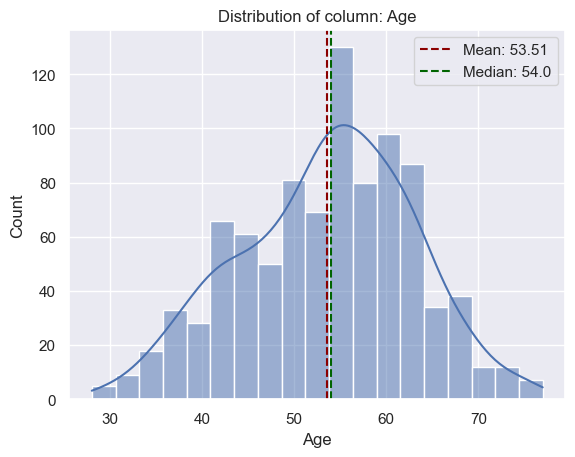

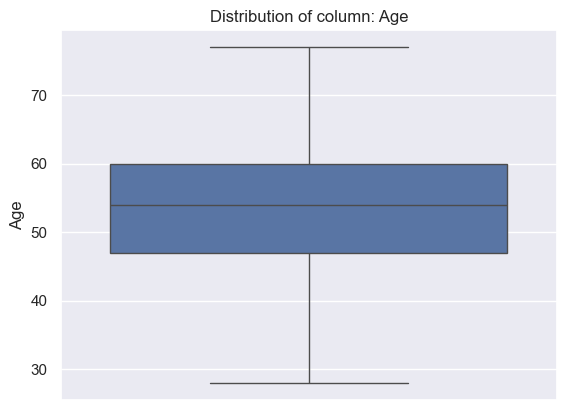

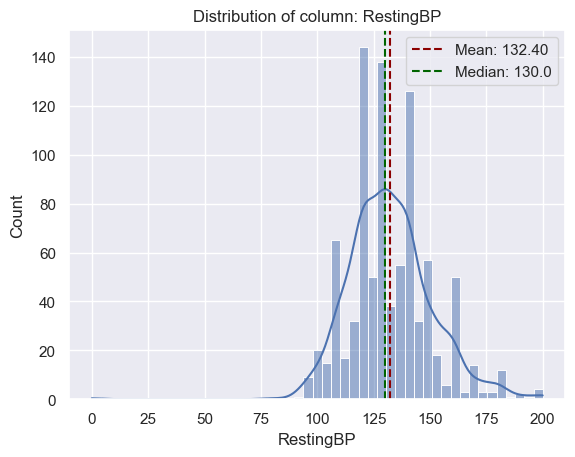

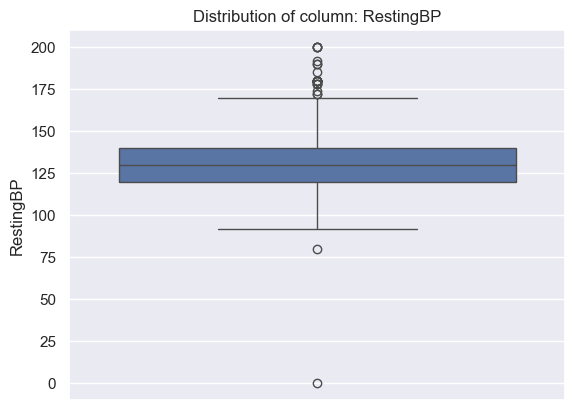

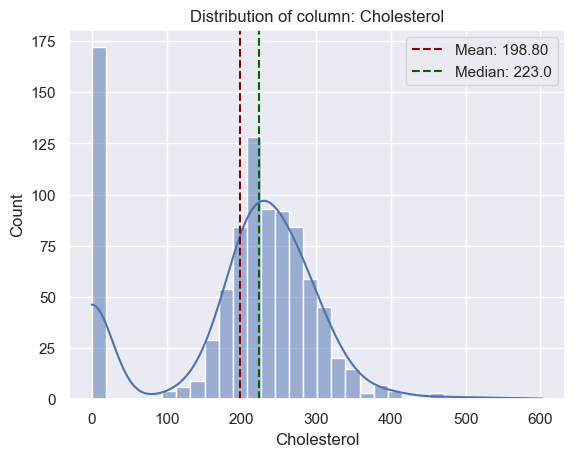

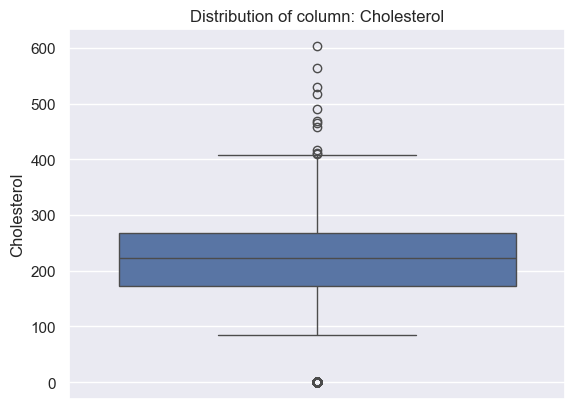

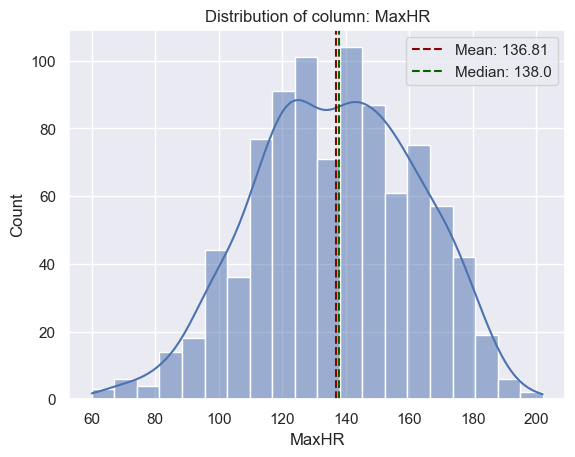

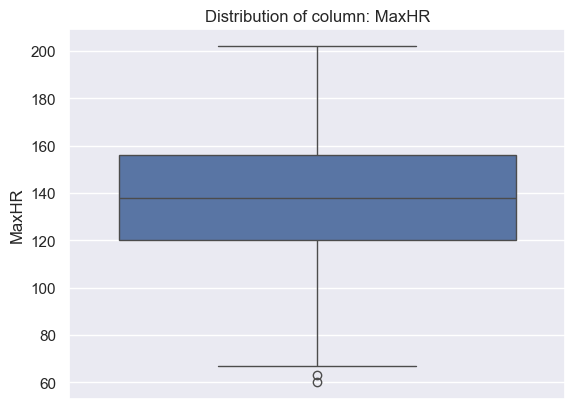

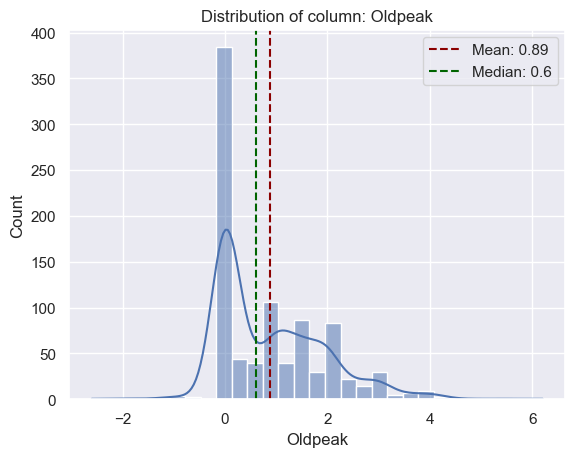

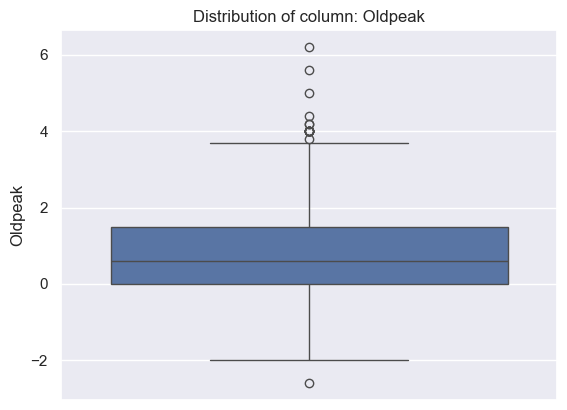

In [12]:
# for each numeric column
for col in quantitative_features:
    plot_hist(df=df, column=col)
    plt.show()
    plot_box(df=df, column1=col)
    plt.show()